In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
import xarray as xr
import rioxarray as rio


from scipy.ndimage import gaussian_filter

import pyproj
import maplookup

# import pandas as pd
import polars as pl

In [3]:
from density_core import DensityCore

S51 = DensityCore.load("_prepared_data/S5-1hxct_density_core.pkl")
S52 = DensityCore.load("_prepared_data/S5-2adj_density_core.pkl")
EG = DensityCore.load("_prepared_data/EGRIP_density_core.pkl")

cores = [EG, S51, S52]

In [4]:
from scipy.interpolate import RegularGridInterpolator

vx, vy = maplookup.load_vxvy(cores[0].lat, cores[0].lon, w=100000, smoothing_sigma=500, source="dtu")
vx.data[np.abs(vx) > 1e7] = np.nan
vx = vx.rio.write_crs("epsg:3413", inplace=True)
vy = vy.rio.write_crs("epsg:3413", inplace=True)

e1, e2 = maplookup.calc_e1e2(vx, vy)

tsxvx, tsxvy = maplookup.load_vxvy(cores[0].lat, cores[0].lon, w=100000, smoothing_sigma=250, source="tsx")
tsxe1, tsxe2 = maplookup.calc_e1e2(tsxvx, tsxvy)


tsxvx = tsxvx.rio.reproject_match(vx)
tsxvy = tsxvy.rio.reproject_match(vy)
tsxe1 = tsxe1.rio.reproject_match(e1)
tsxe2 = tsxe2.rio.reproject_match(e2)
vx.data[~np.isnan(tsxvx.data)] = tsxvx.data[~np.isnan(tsxvx.data)]
vy.data[~np.isnan(tsxvy.data)] = tsxvy.data[~np.isnan(tsxvy.data)]
e1.data[~np.isnan(tsxe1.data)] = tsxe1.data[~np.isnan(tsxe1.data)]
e2.data[~np.isnan(tsxe2.data)] = tsxe2.data[~np.isnan(tsxe2.data)]


vxinterp = RegularGridInterpolator((vx.x.values, vx.y.values), vx.data.T)
vyinterp = RegularGridInterpolator((vy.x.values, vy.y.values), vy.data.T)
e1interp = RegularGridInterpolator((e1.x.values, e1.y.values), e1.data.T)
e2interp = RegularGridInterpolator((e2.x.values, e2.y.values), e2.data.T)


minusv = lambda t, xy: -np.array([vxinterp(xy), vyinterp(xy)]).squeeze()

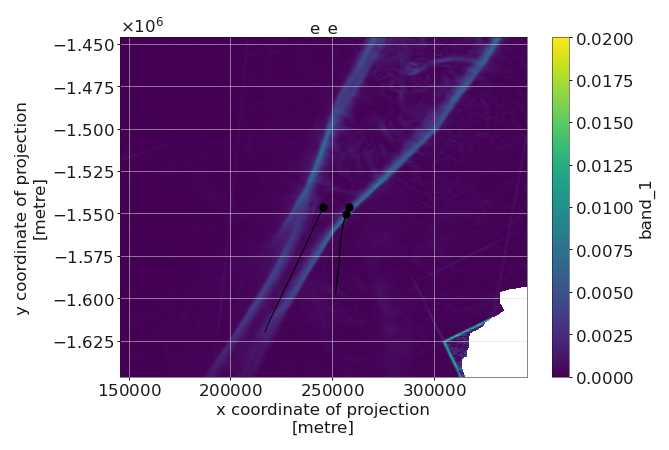

In [ ]:
t = np.arange(0, 2000)

core = cores[0]
from scipy.integrate import solve_ivp

np.sqrt(e1**2 + e2**2).plot.imshow(vmin=0, vmax=0.02)

plt.title("e_e")


for core in cores:
    mapproj = pyproj.Transformer.from_crs("epsg:4326", "epsg:3413")
    x0, y0 = mapproj.transform(core.lat, core.lon)
    soln = solve_ivp(minusv, [t[0], t[-1]], np.array((x0, y0)), t_eval=t)
    pos = soln.y.T
    output = {"t": t, "x": pos[:, 0], "y": pos[:, 1], "vx": vxinterp(pos), "vy": vyinterp(pos), "e1": e1interp(pos), "e2": e2interp(pos)}

    plt.plot(pos[:, 0], pos[:, 1], "k", lw=0.4)
    plt.plot(x0, y0, "ko")

    df = pl.DataFrame(output)

    outputfolder = "_prepared_data"

    # df.to_parquet(f"{outputfolder}/{core.site_name}_backtrajectory.parquet", index=False)
    df.write_parquet(f"{outputfolder}/{core.site_name}_backtrajectory.parquet")

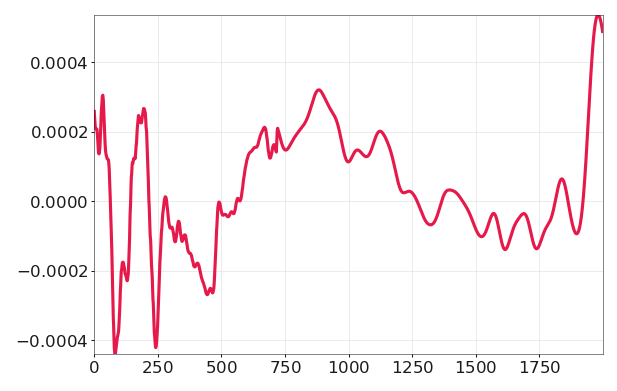

In [6]:
plt.plot(df["e1"] + df["e2"])

dtu
tsx


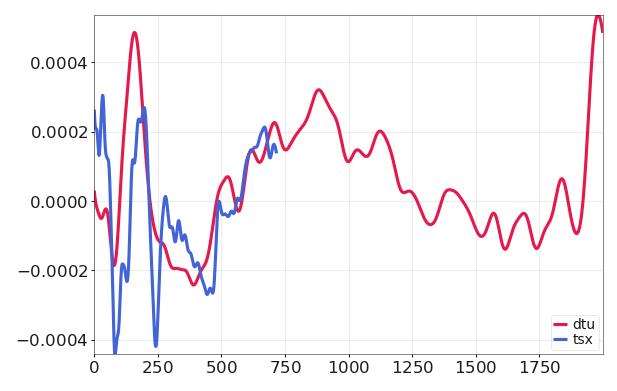

In [20]:
sources = ["dtu", "tsx"]  # , "itslive", "measures"]

for source in sources:
    print(source)
    vx, vy = maplookup.load_vxvy(cores[0].lat, cores[0].lon, w=100000, smoothing_sigma=250 + 250 * (source == "dtu"), source=source)
    vx.data[np.abs(vx) > 1e7] = np.nan
    e1, e2 = maplookup.calc_e1e2(vx, vy)

    e1interp = RegularGridInterpolator((e1.x.values, e1.y.values), e1.data.T, bounds_error=False, fill_value=np.nan)
    e2interp = RegularGridInterpolator((e2.x.values, e2.y.values), e2.data.T, bounds_error=False, fill_value=np.nan)

    plt.plot(e1interp(pos) + e2interp(pos), label=source)

plt.legend()

In [21]:
pd

NameError: name 'pd' is not defined

In [ ]:
vx = vx.rio.write_crs("epsg:3413")
vx.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / NSIDC Sea Ice Polar Stereographic North",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",70],PARAMETER["central_meridian",-45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH],AUTHORITY["EPSG","3413"]]')

In [ ]:
vx.x.shape, vx.y.shape, vx.data.shape

((2219,), (2798,), (2798, 2219))

In [16]:
tsxvx.rio.crs

CRS.from_wkt('PROJCS["Stereographic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",70],PARAMETER["central_meridian",-45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",SOUTH],AXIS["Northing",SOUTH]]')

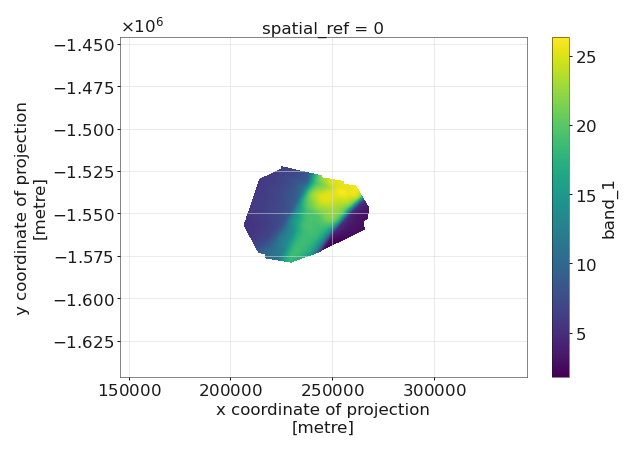

In [4]:
tsxvx.rio.reproject_match(vx).plot.imshow()

In [ ]:
plt.plot()